In [1]:
import math
import warnings
from typing import Any, Dict, Tuple

import jax
from jax import numpy as jnp

from matplotlib import pyplot as plt

from blueprint.qubits import HarmonicOscillator, TunableTransmon
from blueprint.devices import Device
from blueprint.util.index import get_branch_inds
from blueprint.util.quantum import expectation_value

jax.config.update("jax_enable_x64", True)  # Double

In [2]:
def get_figsize(
    columns: int = 1, fig_width : float | None = None, fig_height: float | None = None, width_scale: float = 1.0, height_scale: float = 1.0
) -> Tuple[float, float]:
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    MAX_HEIGHT = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = (
            3.4 if columns == 1 else 7
        )  # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > MAX_HEIGHT:
        warnings.warn(
            "Figure height {} is too large, setting to {}"
            "inches instead".format(fig_height, MAX_HEIGHT)
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs: Any) -> Dict[str, Any]:
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps",
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,
        "font.family": "serif",
    }
    params.update(kwargs)
    return params

Define the units

In [3]:
# units
GHz = 2 * math.pi
MHz = 2 * 1e-3 * math.pi

Create the qubit, a transmon in this case.

In [4]:
QUBIT_LABEL: str = "transmon"
CHARGING_ENERGY: float = 0.22 * GHz
JOSEPHSON_ENERGY: float = 110 * 0.22 * GHz
COUPLING: float = 120 * MHz
OFFSET_CHARGE: float = 0.0
ASYMMETRY: float = 0.0
EXT_FLUX: float = 0.0
CHARGE_CUTOFF: int = 200
QUBIT_DIM: int = 16

qubit = TunableTransmon(
    label=QUBIT_LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
)
qubit.diagonalize(truncated_dim=QUBIT_DIM)

Create the resonator to which the qubit is coupled to

In [5]:

RES_LABEL: str = "resonator"
RES_FREQ: float = 7.5 * GHz
RES_IMPEDENCE: float = 50.0
RES_DIM: int = 300

resonator = HarmonicOscillator.from_frequency(
    label=RES_LABEL,
    frequency=RES_FREQ,
    impedence=RES_IMPEDENCE,
    dim=RES_DIM,
)

Create the device consisting of the qubit-resonator system and add the coupling between the two qubits

In [6]:
COUPLING: float = 120 * MHz

device = Device((qubit, resonator))
device.add_capacative_coupling(("transmon", "resonator"), "coupling", COUPLING / resonator.charge_zpf)

Perform the branch analysis

In [7]:
hamiltonian = device.get_hamiltonian()
energies, states = device.get_eigenstates()

ground_inds = jnp.argmax(jnp.abs(states[::RES_DIM]), axis=1)

raise_op = resonator.get_raise_op()
inds = get_branch_inds(states, raise_op, ground_inds)

branch_energies = energies[inds]
branches = states[:, inds]

qubit_num_op = qubit.get_number_op()
res_num_op = resonator.get_number_op()

res_populations = jnp.real(expectation_value(branches, res_num_op))
qubit_populations = jnp.real(expectation_value(branches, qubit_num_op))

res_populations = res_populations.reshape(QUBIT_DIM, RES_DIM)
qubit_populations = qubit_populations.reshape(QUBIT_DIM, RES_DIM)

Plot the results

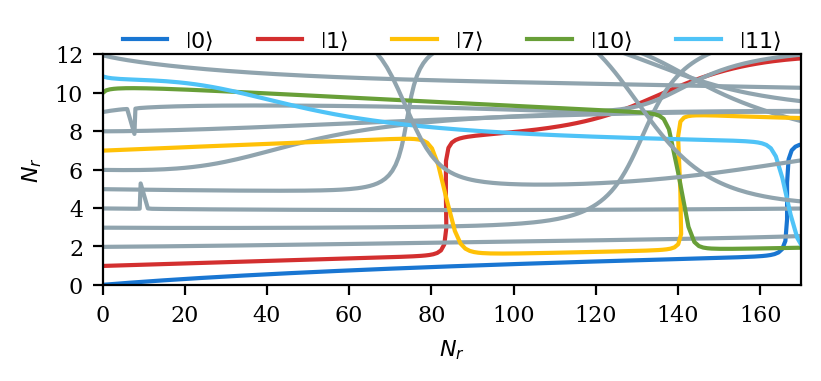

In [8]:
figsize = get_figsize(width_scale=1.25)  # Use the recommended figure size for two-column figures
rc_params = get_rc_params()  # Use the recommended rc params

highlighted_states = (0, 1, 7, 10, 11)
colors = ["#1976d2", "#d32f2f", "#ffc107", "#689f38", "#4fc3f7"]
default_color = "#90a4ae"

states = list(range(QUBIT_DIM))

with plt.rc_context(rc=rc_params):
    fig, ax = plt.subplots(figsize=figsize, sharex=True, tight_layout=True, dpi=200)

    for state in states:
        if state in highlighted_states:
            state_ind = highlighted_states.index(state)
            color = colors[state_ind]
            label = f"$\\left\\vert {{{state}}} \\right\\rangle$"
        else: 
            color = default_color
            label = None
        ax.plot(res_populations[state], qubit_populations[state], color=color, label=label)

    ax.legend(ncols=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.2))
    ax.set_xlim(0, 170)
    ax.set_xticks([0, 20, 40, 60, 80, 100, 120, 140, 160])
    ax.set_xlabel(r"$N_{r}$")

    ax.set_ylim(0, 12)
    ax.set_yticks([0, 2, 4, 6, 8, 10, 12])
    ax.set_ylabel(r"$N_{r}$")

plt.show()


In [9]:
energies_reshaped = branch_energies.reshape(QUBIT_DIM, RES_DIM)
chi = (energies_reshaped[1][1] - energies_reshaped[1][0] - energies_reshaped[0][1] + energies_reshaped[0][0]) / 2


In [10]:
transmon_freq = energies_reshaped[1][0] - energies_reshaped[0][0]

print(transmon_freq / GHz)

6.275221285985602


In [11]:
print(resonator.charge_zpf)

3.1207545372303814e+17
